In [1]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = loadmat("../data/raw/Group 1/G1_Cell1_Data.mat")

In [3]:
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data_cell'])


In [4]:
print(type(data['data_cell']))
print(data['data_cell'].shape)

<class 'numpy.ndarray'>
(1, 612)


In [5]:
cycle1 = data['data_cell'][0,0]

In [6]:
print(type(cycle1))
print(cycle1.dtype)

<class 'numpy.ndarray'>
[('chg_Time_s', 'O'), ('chg_Voltage_V', 'O'), ('chg_Current_mA', 'O'), ('chg_Capacity_mAh', 'O'), ('chg_StepID', 'O'), ('dischg_Time_s', 'O'), ('dischg_Voltage_V', 'O'), ('dischg_Current_mA', 'O'), ('dischg_Capacity_mAh', 'O'), ('dischg_StepID', 'O'), ('fullCycle_Time_s', 'O'), ('fullCycle_Voltage_V', 'O'), ('fullCycle_Current_mA', 'O'), ('fullCycle_StepID', 'O'), ('fullCycle_SoC', 'O')]


In [7]:
chg_voltage = cycle1['chg_Voltage_V'][0,0]
chg_time = cycle1['chg_Time_s'][0,0]
print(chg_voltage.shape)
print(chg_time.shape)

(642, 1)
(642, 1)


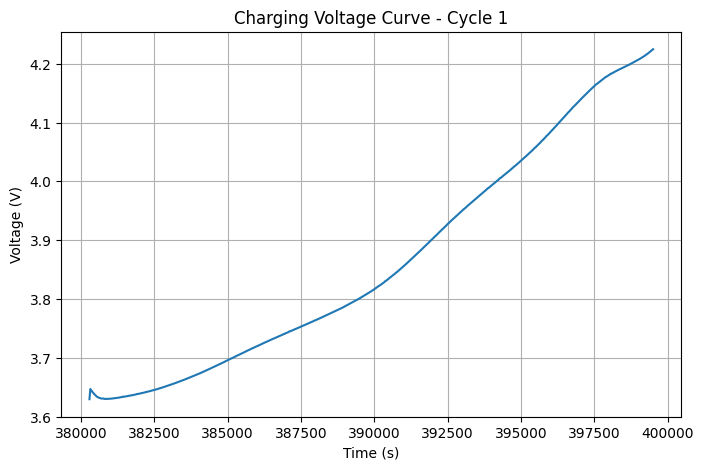

In [8]:
plt.figure(figsize=(8,5))
plt.plot(chg_time, chg_voltage)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Charging Voltage Curve - Cycle 1")
plt.grid(True)
plt.show()

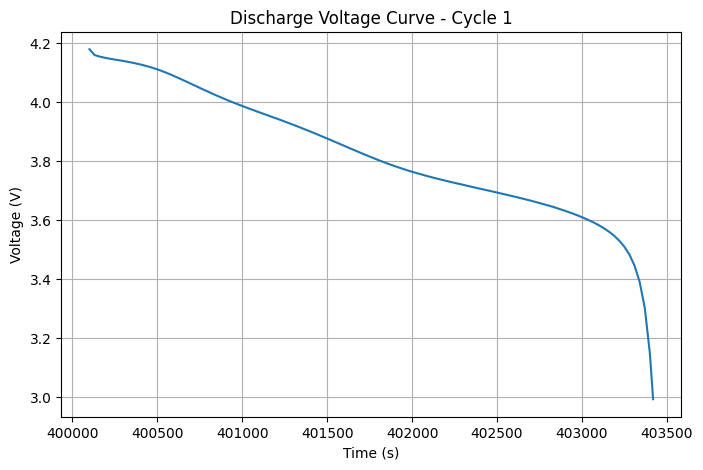

In [9]:
dischg_voltage = cycle1['dischg_Voltage_V'][0,0]
dischg_time = cycle1['dischg_Time_s'][0,0]

plt.figure(figsize=(8,5))

plt.plot(dischg_time, dischg_voltage)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Discharge Voltage Curve - Cycle 1")

plt.grid(True)
plt.show()

In [10]:
dischg_capacity = cycle1['dischg_Capacity_mAh'][0,0]
chg_capacity = cycle1['chg_Capacity_mAh'][0,0]

print(dischg_capacity.shape)
print(chg_capacity.shape)

print(dischg_capacity[:5])

(112, 1)
(642, 1)
[[-0.        ]
 [ 0.03118333]
 [ 0.06236667]
 [ 0.09355   ]
 [ 0.12473333]]


In [11]:
final_capacity = dischg_capacity[-1,0]
print("Final discharge capacity:",final_capacity,"mAh")

Final discharge capacity: 3.4502661111111292 mAh


In [12]:
num_cycles = data['data_cell'].shape[1]
capacities = []
for i in range(num_cycles):
    cycle = data['data_cell'][0,i]
    dischg_capacity = cycle['dischg_Capacity_mAh'][0,0]
    final_capacity = dischg_capacity[-1,0]
    capacities.append(final_capacity)
print("Number of cycles:",len(capacities))
print("First 5 capacities:")
print(capacities[:5]) 

Number of cycles: 612
First 5 capacities:
[np.float64(3.4502661111111292), np.float64(3.706767499999983), np.float64(3.8396233333333396), np.float64(3.782258055555597), np.float64(3.72737666666658)]


In [13]:
cycles = np.arrange(1,num_cycles + 1)
plt.figure(figsize=(10,5))
plt.plot(cycles,capacities)
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (mAh)")
plt.title("Battery Capacity Degradation")
plt.grid(True)
plt.show()

AttributeError: module 'numpy' has no attribute 'arrange'

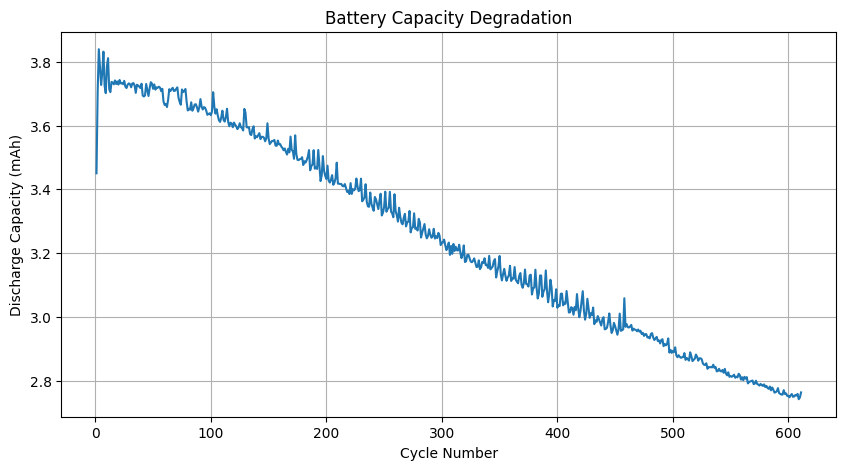

In [14]:
cycles = np.arange(1, num_cycles + 1)
plt.figure(figsize=(10,5))
plt.plot(cycles, capacities)
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (mAh)")
plt.title("Battery Capacity Degradation")
plt.grid(True)
plt.show()

In [15]:
initial_capacity = capacities[0]

soh = np.array(capacities) / initial_capacity

print("First 5 SOH values:")
print(soh[:5])

First 5 SOH values:
[1.         1.07434249 1.11284846 1.09622213 1.08031571]


In [16]:
reference_capacity = max(capacities)

soh = np.array(capacities) / reference_capacity

print("Reference capacity:", reference_capacity)

print("First 5 SOH values:")
print(soh[:5])

Reference capacity: 3.8396233333333396
First 5 SOH values:
[0.89859494 0.96539873 1.         0.98505966 0.97076623]


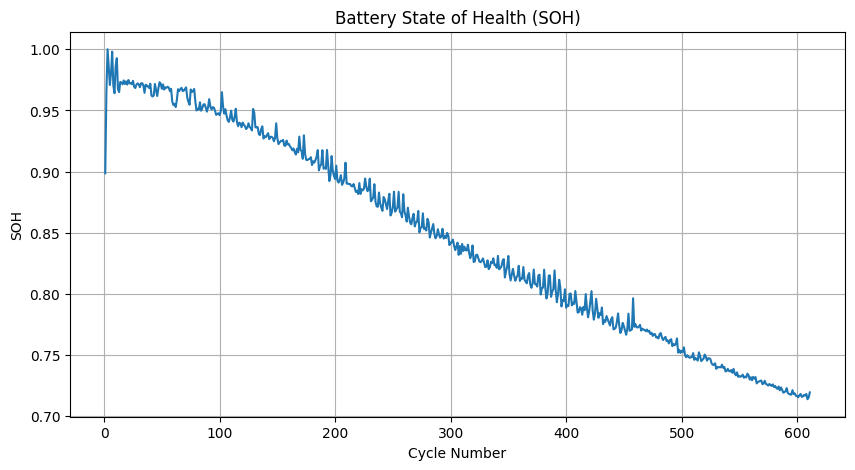

In [17]:
plt.figure(figsize=(10,5))

plt.plot(cycles, soh)

plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("Battery State of Health (SOH)")

plt.grid(True)
plt.show()